# Statisticka analiza skupa *FIFA World Cup 2026 Player Performance*

U ovom rjesenju analiziraju se podaci o igracima sa Svjetskog prvenstva 2026. Cilj je provesti predobradu podataka, eksplorativnu analizu, statisticke testove i nekoliko modela kako bismo bolje razumjeli koji su pokazatelji povezani s igrackom ocjenom player_rating.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.multivariate.manova import MANOVA


# Ucitavanje i predobrada podataka

In [39]:
data_path = "fifa_world_cup_2026_player_performance.csv"

data = pd.read_csv(data_path)
broj_redaka_pocetno, broj_stupaca_pocetno = data.shape

df = data.copy()

df.columns = df.columns.str.strip().str.lower()
df.columns = df.columns.str.replace(" ", "_")

print(df.duplicated().sum())
df = df.drop_duplicates()

df_clean = df[df["minutes_played"] > 0].copy()
df = df_clean.copy()

odabrane_varijable = [
    "age",
    "position",
    "match_result",
    "minutes_played",
    "goals",
    "assists",
    "shots_on_target",
    "distance_covered_km",
    "stamina_score",
    "player_rating",
    "creativity_score",
    "consistency_score",
    "clutch_performance_score",
]

df["rating_group"] = "Srednja (6.0-6.9)"
df.loc[df["player_rating"] < 6.0, "rating_group"] = "Niza (<6.0)"
df.loc[df["player_rating"] >= 7.0, "rating_group"] = "Visa (7.0+)"

print(df.shape)
print(df.info())
print(df[odabrane_varijable].head())
print(df[odabrane_varijable].describe())

0
(31558, 76)
<class 'pandas.core.frame.DataFrame'>
Index: 31558 entries, 0 to 54587
Data columns (total 76 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_id                 31558 non-null  object 
 1   player_name               31558 non-null  object 
 2   age                       31558 non-null  int64  
 3   nationality               31558 non-null  object 
 4   team                      31558 non-null  object 
 5   jersey_number             31558 non-null  int64  
 6   position                  31558 non-null  object 
 7   height_cm                 31558 non-null  int64  
 8   weight_kg                 31558 non-null  int64  
 9   preferred_foot            31558 non-null  object 
 10  club_name                 31558 non-null  object 
 11  market_value_eur          31558 non-null  int64  
 12  match_id                  31558 non-null  object 
 13  match_date                31558 non-null  object 
 1

Rezultat predobrade pokazuje da je nakon ciscenja zadrzano 31558 zapisa i 76 varijabli, bez duplikata i bez igraca s minutazom jednakom 0. Time je dobiven uredan skup podataka u kojem svaki redak predstavlja stvarni igracki nastup, pa su daljnje analize pouzdanije i smislenije.


# EDA i statisticki testovi

U ovom dijelu posebna se paznja stavlja na varijablu player_rating, jer ona najbolje predstavlja ukupnu individualnu izvedbu igraca. Najprije se promatraju deskriptivne statistike i srednje vrijednosti, a zatim se provode vizualizacije i testovi kojima se ispituju razlike izmedu grupa.

In [42]:
key_summary = df[
    [
        "player_rating",
        "age",
        "minutes_played",
        "goals",
        "assists",
        "shots_on_target",
        "distance_covered_km",
        "stamina_score",
        "creativity_score",
        "consistency_score",
        "clutch_performance_score",
    ]
].describe().T

position_mean = df.groupby("position")["player_rating"].mean()
position_median = df.groupby("position")["player_rating"].median()
position_std = df.groupby("position")["player_rating"].std()
position_count = df.groupby("position")["player_rating"].count()

result_mean = df.groupby("match_result")["player_rating"].mean()
result_median = df.groupby("match_result")["player_rating"].median()
result_std = df.groupby("match_result")["player_rating"].std()
result_count = df.groupby("match_result")["player_rating"].count()

print(key_summary)

overall_mean = df["player_rating"].mean()
overall_median = df["player_rating"].median()
overall_std = df["player_rating"].std()

group_means_position = df.groupby("position")["player_rating"].mean()
group_means_result = df.groupby("match_result")["player_rating"].mean()

print(group_means_position)
print(group_means_result)

                            count       mean        std   min   25%   50%  \
player_rating             31558.0   6.288567   0.736102   3.6   5.8   6.3   
age                       31558.0  26.175328   4.014956  17.0  23.0  26.0   
minutes_played            31558.0  62.631029  25.286945   5.0  40.0  72.0   
goals                     31558.0   0.095824   0.325440   0.0   0.0   0.0   
assists                   31558.0   0.089644   0.307576   0.0   0.0   0.0   
shots_on_target           31558.0   0.083782   0.316967   0.0   0.0   0.0   
distance_covered_km       31558.0   6.914541   2.797708   2.0   4.4   7.5   
stamina_score             31558.0  86.978094   8.224039  50.0  81.3  87.3   
creativity_score          31558.0  47.117507  22.603628   5.0  30.4  41.6   
consistency_score         31558.0  63.890560  19.904378  25.0  46.6  61.3   
clutch_performance_score  31558.0  55.577226  13.736876  15.0  46.4  55.0   

                           75%   max  
player_rating              6.8   9.4

Deskriptivna statistika pokazuje da prosjecni player_rating u uzorku iznosi 6.289, uz medijan 6.3 i standardnu devijaciju oko 0.736. Po pozicijama najvise prosjecne ocjene imaju napadaci (6.355), a najnize vratari (6.205), dok po ishodu utakmice igraci u pobjedama imaju vise prosjecne ocjene (6.383) nego igraci u porazima (6.233) i nerijesenim susretima (6.235).


## Vizualizacija podataka

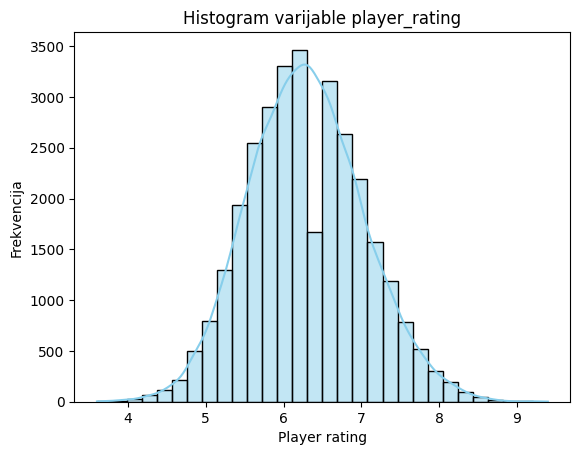

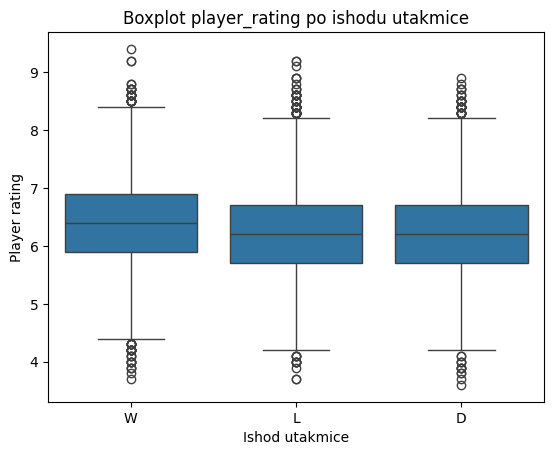

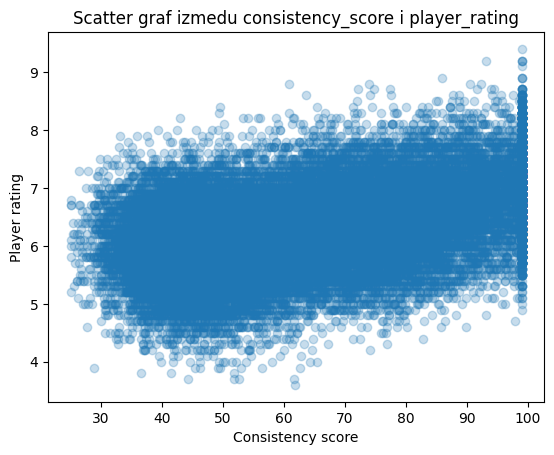

In [45]:
sns.histplot(df["player_rating"], bins=30, kde=True, color="skyblue")
plt.title("Histogram varijable player_rating")
plt.xlabel("Player rating")
plt.ylabel("Frekvencija")
plt.show()

sns.boxplot(data=df, x="match_result", y="player_rating")
plt.title("Boxplot player_rating po ishodu utakmice")
plt.xlabel("Ishod utakmice")
plt.ylabel("Player rating")
plt.show()

plt.scatter(df["consistency_score"], df["player_rating"], alpha=0.25)
plt.title("Scatter graf izmedu consistency_score i player_rating")
plt.xlabel("Consistency score")
plt.ylabel("Player rating")
plt.show()

Histogram pokazuje da je vecina vrijednosti player_rating koncentrirana oko srednjih ocjena, bez izrazito velikog rasprsenja. Boxplot pokazuje da su ocjene u pobjedama pomaknute prema visim vrijednostima nego u porazima i nerijesenim utakmicama. Dijagram rasprsenja dodatno pokazuje pozitivan odnos izmedu consistency_score i player_rating, sto sugerira da igraci s vecom konzistentnoscu u pravilu ostvaruju i bolje ocjene.


## Usporedba igraca u pobjedama i porazima

In [47]:
wl_df = df[df["match_result"].isin(["W", "L"])]

wins = wl_df[wl_df["match_result"] == "W"]["player_rating"]
losses = wl_df[wl_df["match_result"] == "L"]["player_rating"]

print(stats.shapiro(wins))
print(stats.shapiro(losses))

u, p = stats.mannwhitneyu(wins, losses)

print(f"U statistika = {u:.2f}")
print(f"p-vrijednost = {p:.4f}")

if p < 0.05:
    print("Postoji statisticki znacajna razlika u varijabli player_rating izmedu pobjeda i poraza.")
else:
    print("Ne postoji statisticki znacajna razlika u varijabli player_rating izmedu pobjeda i poraza.")

ShapiroResult(statistic=np.float64(0.9976191152976495), pvalue=np.float64(1.3517242042130597e-12))
ShapiroResult(statistic=np.float64(0.9962489073153065), pvalue=np.float64(1.023655336484741e-16))
U statistika = 75808139.50
p-vrijednost = 0.0000
Postoji statisticki znacajna razlika u varijabli player_rating izmedu pobjeda i poraza.


Shapiro-Wilkovi testovi za skupinu pobjeda i skupinu poraza imaju vrlo male p-vrijednosti, pa pretpostavka normalnosti nije zadovoljena. Zbog toga je primijenjen Mann-Whitney U test, koji daje p-vrijednost 0.0000. Rezultat pokazuje da postoji statisticki znacajna razlika u player_rating izmedu pobjeda i poraza, pri cemu igraci u pobjednickim utakmicama ostvaruju vise ocjene.


## Hi-kvadrat test nezavisnosti

rating_group  Niza (<6.0)  Srednja (6.0-6.9)  Visa (7.0+)
position                                                 
Defender             4033               5614         1837
Forward              2320               3763         1617
Goalkeeper            757               1039          304
Midfielder           3304               5008         1962
Chi-square statistika: 127.74938409847158, P-vrijednost: 3.8264629231563076e-25


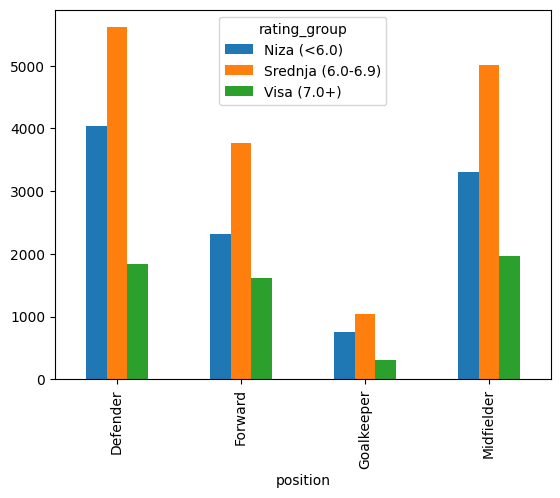

In [48]:
kontingencijska_tablica = pd.crosstab(df["position"], df["rating_group"])
chi2, p, dof, expected = stats.chi2_contingency(kontingencijska_tablica)

print(kontingencijska_tablica)
print(f"Chi-square statistika: {chi2}, P-vrijednost: {p}")

kontingencijska_tablica.plot(kind="bar")
plt.show()

Kontingencijska tablica pokazuje da se nize, srednje i vise ocjene ne pojavljuju jednako u svim pozicijama. Hi-kvadrat test daje vrijednost statistike 127.749 uz p-vrijednost 3.83e-25, pa se moze zakljuciti da postoji statisticki znacajna povezanost izmedu pozicije igraca i kategorije ocjene. To znaci da je raspodjela ocjena djelomicno povezana s igrackom ulogom na terenu.


# Izrada linearnih modela za predvidanje ocjene igraca

Nakon eksplorativne analize i osnovnih testova prelazi se na modeliranje. Cilj je ispitati moze li se ocjena igraca objasniti pomocu pojedinih pokazatelja ucinkovitosti te koliko su ti prediktori statisticki znacajni.

In [49]:
data_reg = df[["consistency_score", "player_rating"]].dropna()

X = data_reg["consistency_score"]
Y = data_reg["player_rating"]

slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

print(f"Nagib pravca b1 = {slope:.4f}")
print(f"Odsjecak na y-os b0 = {intercept:.4f}")
print(f"Koeficijent korelacije (r) = {r_value:.4f}")
print(f"Koeficijent determinacije (R^2) = {r_value**2:.4f}")
print(f"P-vrijednost = {p_value:.4f}")

X_sm = sm.add_constant(X)
model_sm = sm.OLS(Y, X_sm).fit()
print(model_sm.summary())

conf_int_b1 = model_sm.conf_int().loc["consistency_score"]
print(f"95% interval pouzdanosti za nagib: [{conf_int_b1[0]:.4f}, {conf_int_b1[1]:.4f}]")

y_pred = intercept + slope * X
residuals = Y - y_pred

n = len(X)
F = (r_value**2 / (1 - r_value**2)) * (n - 2)
print(f"F-statistika = {F:.4f}")

print(
    f"Jednadzba regresijskog pravca glasi: player_rating = {intercept:.3f} + {slope:.3f} * consistency_score."
)
print(
    f"Vrijednost R^2 iznosi {r_value**2:.3f}, sto pokazuje koliko model objasnjava varijabilnost varijable player_rating."
)
print(
    f"Buduci da je p-vrijednost jednaka {p_value:.4f}, mozemo zakljuciti da postoji statisticki znacajna linearna povezanost izmedu consistency_score i player_rating."
)

Nagib pravca b1 = 0.0171
Odsjecak na y-os b0 = 5.1957
Koeficijent korelacije (r) = 0.4625
Koeficijent determinacije (R^2) = 0.2139
P-vrijednost = 0.0000
                            OLS Regression Results                            
Dep. Variable:          player_rating   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     8588.
Date:                Mon, 06 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:19:33   Log-Likelihood:                -31311.
No. Observations:               31558   AIC:                         6.263e+04
Df Residuals:                   31556   BIC:                         6.264e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P

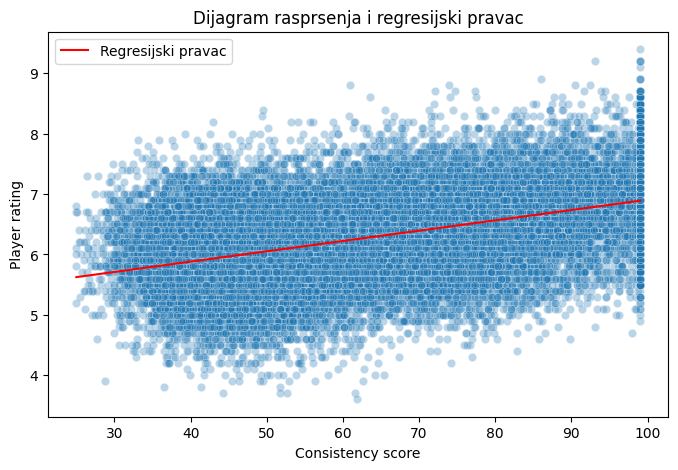

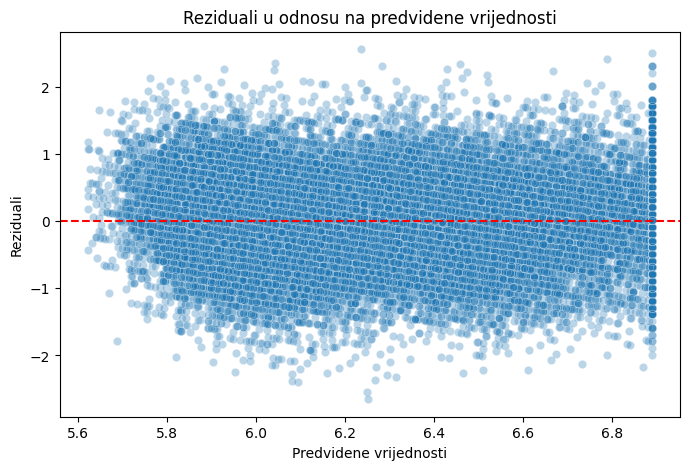

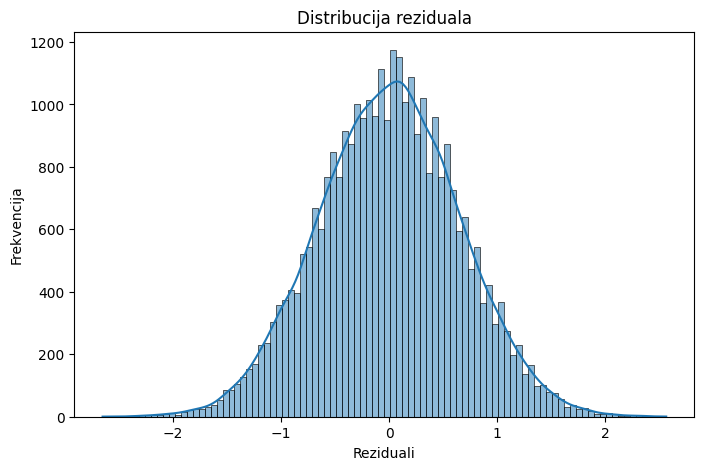

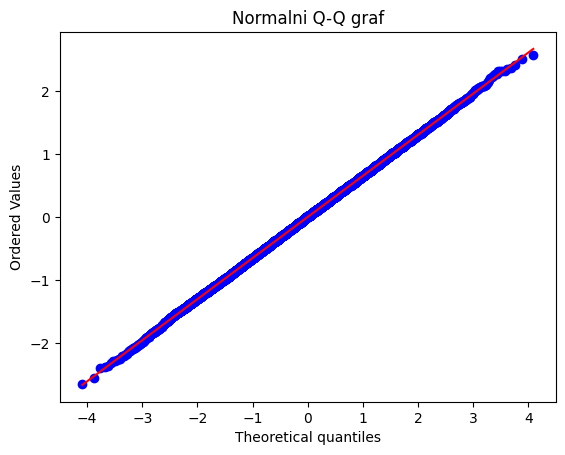

ShapiroResult(statistic=np.float64(0.9996488701956209), pvalue=np.float64(0.5520081697993651))


In [50]:
x_sort = np.sort(X)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=X, y=Y, alpha=0.3)
plt.plot(x_sort, intercept + slope * x_sort, color="red", label="Regresijski pravac")
plt.title("Dijagram rasprsenja i regresijski pravac")
plt.xlabel("Consistency score")
plt.ylabel("Player rating")
plt.legend()
plt.show()

y_pred = intercept + slope * X
residuals = Y - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.title("Reziduali u odnosu na predvidene vrijednosti")
plt.xlabel("Predvidene vrijednosti")
plt.ylabel("Reziduali")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribucija reziduala")
plt.xlabel("Reziduali")
plt.ylabel("Frekvencija")
plt.show()

plt.figure()
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Normalni Q-Q graf")
plt.show()

print(stats.shapiro(residuals.sample(min(5000, len(residuals)), random_state=42)))

Jednostavna linearna regresija pokazuje statisticki znacajan pozitivan odnos izmedu consistency_score i player_rating. Koeficijent nagiba iznosi 0.0171, sto znaci da se s porastom consistency_score za jedan bod prosjecni player_rating povecava za oko 0.017 bodova. Vrijednost R^2 iznosi 0.214, pa model objasnjava oko 21.4% varijabilnosti ocjene igraca, dok dijagnosticki grafovi ne upucuju na velika odstupanja od osnovnih pretpostavki modela.


## Visestruka linearna regresija

In [51]:
prediktori = [
    "goals",
    "assists",
    "shots_on_target",
    "consistency_score",
    "clutch_performance_score",
]

df_multi = df[
    [
        "player_rating",
        "goals",
        "assists",
        "shots_on_target",
        "consistency_score",
        "clutch_performance_score",
    ]
].copy()

X = df_multi[prediktori]
y = df_multi["player_rating"]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

print(f"Koeficijent determinacije R^2 iznosi {model.rsquared:.3f}.")
print(f"Prilagodeni R^2 iznosi {model.rsquared_adj:.3f}.")
print(
    f"F-statistika modela iznosi {model.fvalue:.3f}, a pripadna p-vrijednost {model.f_pvalue:.4f}."
)
print(
    "Na temelju dobivenih rezultata moze se procijeniti koliko skup odabranih varijabli objasnjava promjene u varijabli player_rating."
)

                            OLS Regression Results                            
Dep. Variable:          player_rating   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     2053.
Date:                Mon, 06 Jul 2026   Prob (F-statistic):               0.00
Time:                        20:22:44   Log-Likelihood:                -30665.
No. Observations:               31558   AIC:                         6.134e+04
Df Residuals:                   31552   BIC:                         6.139e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

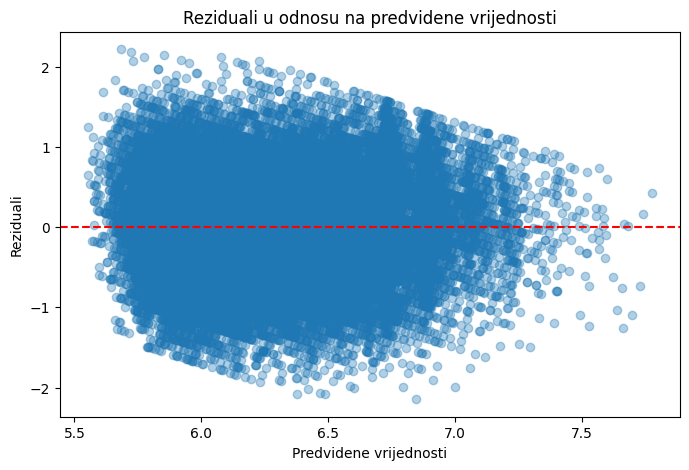

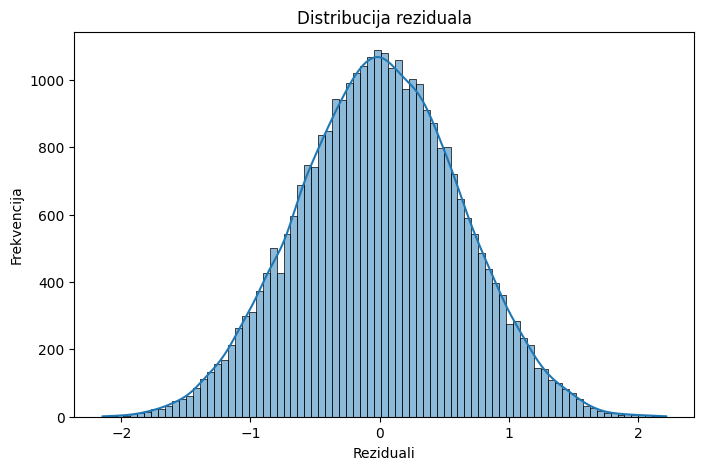

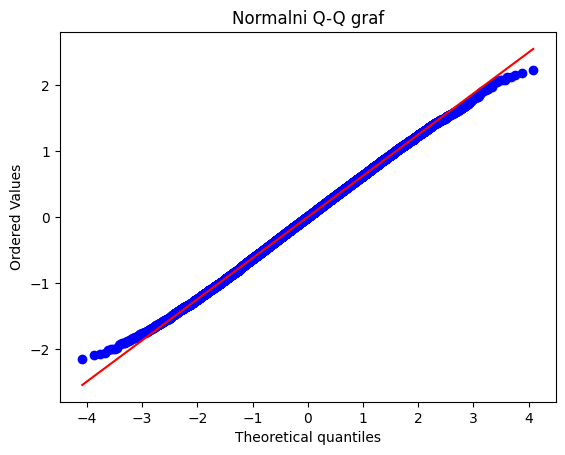

ShapiroResult(statistic=np.float64(0.9992432724538876), pvalue=np.float64(0.029783022310979602))


In [52]:
fitted_multi = multi_model.fittedvalues
residuals_multi = multi_model.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted_multi, residuals_multi, alpha=0.35)
plt.axhline(0, color="red", linestyle="--")
plt.title("Reziduali u odnosu na predvidene vrijednosti")
plt.xlabel("Predvidene vrijednosti")
plt.ylabel("Reziduali")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals_multi, kde=True)
plt.title("Distribucija reziduala")
plt.xlabel("Reziduali")
plt.ylabel("Frekvencija")
plt.show()

plt.figure()
stats.probplot(residuals_multi, dist="norm", plot=plt)
plt.title("Normalni Q-Q graf")
plt.show()

print(stats.shapiro(residuals_multi.sample(min(5000, len(residuals_multi)), random_state=42)))

Rezultati visestruke regresije pokazuju da svi ukljuceni prediktori zadrzavaju statisticku znacajnost kada se promatraju zajedno, iako je shots_on_target na granici znacajnosti. Najvece pozitivne koeficijente imaju goals (0.3225) i assists (0.2233), dok consistency_score ostaje stabilan i vazan prediktor. Vrijednost R^2 iznosi 0.245, sto znaci da skup odabranih varijabli objasnjava oko 24.5% varijabilnosti varijable player_rating.


# Analiza varijance

match_result         D         L         W
position                                  
Defender      6.183300  6.173316  6.339150
Forward       6.298673  6.300459  6.450742
Goalkeeper    6.181884  6.158010  6.269251
Midfielder    6.255106  6.263433  6.404580
Grupa 1: p-vrijednost = 3.3483957900962473e-06
Grupa 2: p-vrijednost = 7.131611232784602e-09
Grupa 3: p-vrijednost = 1.8511612608183518e-06
Grupa 4: p-vrijednost = 2.2695031440499068e-05
Grupa 5: p-vrijednost = 2.363554007641495e-07
Grupa 6: p-vrijednost = 0.00010125460128198802
Grupa 7: p-vrijednost = 0.006419784770439235
Grupa 8: p-vrijednost = 0.023679086232901936
Grupa 9: p-vrijednost = 0.03086820369968179
Grupa 10: p-vrijednost = 8.553339382323093e-06
Grupa 11: p-vrijednost = 2.460752871486469e-08
Grupa 12: p-vrijednost = 7.046875386765099e-06
Levene test p-vrijednost = 4.687275171847882e-05
                                   sum_sq       df           F        PR(>F)
C(position)                     85.668840      3.0   53.47020

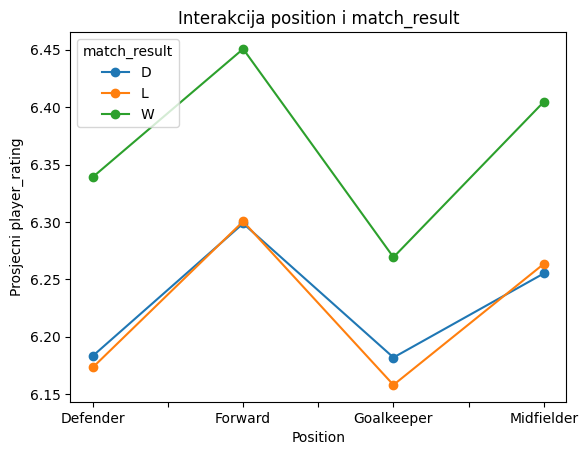

In [55]:
means = df.groupby(["position", "match_result"])["player_rating"].mean().unstack()
print(means)

groups = [group["player_rating"].values for _, group in df.groupby(["position", "match_result"])]

for i, group in enumerate(groups):
    stat, p = stats.shapiro(group)
    print(f"Grupa {i+1}: p-vrijednost = {p}")

stat, p = stats.levene(*groups)
print(f"Levene test p-vrijednost = {p}")

model = smf.ols("player_rating ~ C(position) + C(match_result) + C(position) * C(match_result)", data=df).fit()
anova_results = anova_lm(model, typ=2)
print(anova_results)

means.plot(marker="o")
plt.xlabel("Position")
plt.ylabel("Prosjecni player_rating")
plt.title("Interakcija position i match_result")
plt.show()

Dvofaktorska ANOVA pokazuje da i pozicija igraca i ishod utakmice imaju statisticki znacajan ucinak na player_rating, jer su njihove p-vrijednosti vrlo male. S druge strane, interakcija izmedu pozicije i ishoda nije znacajna (p = 0.6998), sto upucuje na to da se razlike medu pozicijama i razlike medu ishodima uglavnom mogu promatrati odvojeno. Tablica srednjih vrijednosti pritom pokazuje da igraci u pobjedama dosljedno imaju vise prosjecne ocjene unutar svih pozicija.


# Napredna multivarijatna analiza

In [56]:
from statsmodels.multivariate.manova import MANOVA

manova = MANOVA.from_formula(
    "player_rating + clutch_performance_score ~ C(position) + C(match_result) + C(position) * C(match_result)",
    data=df
)

print(manova.mv_test())

                      Multivariate linear model
                                                                     
---------------------------------------------------------------------
         Intercept        Value  Num DF   Den DF     F Value   Pr > F
---------------------------------------------------------------------
            Wilks' lambda 0.1128 2.0000 31545.0000 124053.9814 0.0000
           Pillai's trace 0.8872 2.0000 31545.0000 124053.9814 0.0000
   Hotelling-Lawley trace 7.8652 2.0000 31545.0000 124053.9814 0.0000
      Roy's greatest root 7.8652 2.0000 31545.0000 124053.9814 0.0000
---------------------------------------------------------------------
                                                                     
----------------------------------------------------------------------
        C(position)        Value   Num DF    Den DF    F Value  Pr > F
----------------------------------------------------------------------
            Wilks' lambda  0.9988  6.00

MANOVA pokazuje da i pozicija igraca i ishod utakmice imaju statisticki znacajan zajednicki ucinak na varijable player_rating i clutch_performance_score, jer su Wilksove lambde za oba efekta pracene p-vrijednoscu 0.0000. Nasuprot tome, njihova interakcija nije znacajna (Wilks' lambda = 0.9998, p = 0.9076), pa se ne vidi uvjerljiv zajednicki multivarijatni ucinak ta dva faktora u kombinaciji. To znaci da se siri profil igracke izvedbe mijenja po poziciji i rezultatu utakmice, ali ne i zbog njihove interakcije.


# Zakljucak

Rezultati cijele analize pokazuju da je player_rating povezan i s individualnim pokazateljima izvedbe i s kontekstom utakmice. Igraci u pobjedama u prosjeku imaju vise ocjene nego igraci u porazima, a napadaci i vezni igraci ostvaruju vise prosjecne ocjene od branica i vratara. Regresijski modeli pokazuju da konzistentnost, golovi, asistencije i slicni pokazatelji imaju pozitivan doprinos objasnjenju ocjene, dok ANOVA i MANOVA potvrduju da su pozicija i ishod utakmice vazni i na univarijatnoj i na multivarijatnoj razini.


## Kratki sazetak

Kratko sazeto, rezultati pokazuju da je player_rating najvisi u pobjednickim utakmicama, da se razlikuje medu pozicijama igraca te da je pozitivno povezan s consistency_score, golovima i asistencijama. Time je na jednom nogometnom skupu podataka prikazan niz statistickih postupaka slicnih laboratorijskim vjezbama, ali uz konkretne obrasce vezane uz igracku izvedbu.
